<h1 style="text-align: center;">SMT Challenge 2025 Catch Probability Model</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to develop our version of the catch probability model</h3>

### Necessary Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
baby_red_blue_cmap = LinearSegmentedColormap.from_list("baby_red_blue", ["#89CFF0", "#ffffff", "#CC3433"])
import seaborn as sns
from scipy.stats import norm, gamma
from scipy.optimize import minimize_scalar
from pygam import LogisticGAM, s, f
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, log_loss

## set up the random seed to generate same results
np.random.seed(42)

pd.set_option('display.max_columns', None)

### Helper Functions

In [10]:
def info_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Displays information about the dataframe with # of missing values, unique numbers, datatypes, etc.
    
    Arguments: Dataframe
    """
    df = df.copy()
    dtype = df.dtypes
    num_unique = df.T.apply(lambda x: x.nunique(), axis=1)
    nan_total = df.isnull().sum()
    nan_percent = (df.isnull().sum()/df.isnull().count()*100)
    quality_df = pd.concat([nan_total, nan_percent, num_unique, dtype], axis=1, keys=['total_NaNs', 'NaN%', 'num_unique', 'dtypes'])
    display(quality_df)

In [11]:
def catch_made_hist(df: pd.DataFrame, column: str, ax=None) -> None:
    """
    Displays overlapping histograms between successful catches and not for some column
    
    Arguments: column: is some quantitative column in df
    """
    df = df.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
        
    ax.hist(df[df['is_out_catch'] == 0][column], bins=25, alpha=0.7, label='Made catch == 0', color='#CC3433', density=True)
    ax.hist(df[df['is_out_catch'] == 1][column], bins=25, alpha=0.7, label='Made catch == 1', color='#89CFF0', density=True)
    ax.set_xlabel(column.replace('_', ' '))
    ax.set_ylabel('Density')
    ax.set_title(f"{column.replace('_', ' ')} Histograms\n Comparisons")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

In [12]:
def bootstrap_uniform(data: np.array, n=10_000) -> tuple:
    """
    Uses the bootstrap method to find the 95% CI estimate for alpha and beta of the Uniform distribution

    Arguments: observed_data: a column's values, n: number of iterations
    """
    sample_size = len(data)
    alpha_values = []
    beta_values = []

    ## bootstrap resampling -> finding n randomly estimated alpha's and beta's and putting them into respective lists
    for _ in range(n):
        bootstrap_sample = np.random.choice(data, size=sample_size, replace=True)
        ## sampled alpha & beta
        alpha_hat = np.min(bootstrap_sample)
        alpha_values.append(alpha_hat)
        
        beta_hat = np.max(bootstrap_sample)
        beta_values.append(beta_hat)
    
    ## computing the 95% CI for the estimated alpha and beta
    ## the lower limit alpha value and upper limit alpha value
    alpha_values.sort()
    alpha_lower_limit = alpha_values[int(0.025 * n)]
    alpha_upper_limit = alpha_values[int(0.975 * n)]
    ## the lower limit beta value and upper limit beta value
    beta_values.sort()
    beta_lower_limit = beta_values[int(0.025 * n)]
    beta_upper_limit = beta_values[int(0.975 * n)]

    return np.mean([alpha_lower_limit, alpha_upper_limit]), np.mean([beta_lower_limit, beta_upper_limit])

In [13]:
def accuracy_metric_df(y_test: np.array, y_pred: np.array, y_pred_proba: np.array, model_name: str) -> pd.DataFrame:
    """
    Creates a dataframe of each accuracy metric for model_name
    
    Arguments: y_test: the test labels, y_pred: the predicted test labels, y_pred_proba: the probability of the test labels, model_name: name given for the model
    """
    results = {}
    results['precision'] = precision_score(y_test, y_pred)
    results['recall'] = recall_score(y_test, y_pred)
    results['f1_score'] = f1_score(y_test, y_pred)
    results['roc_auc'] = roc_auc_score(y_test, y_pred_proba)
    results['log_loss'] = log_loss(y_test, y_pred_proba)
    return pd.DataFrame([results], index=[model_name])

In [14]:
def catch_prob_cm(y_test: np.array, y_pred: np.array) -> None:
    """
    Plots the confusion matrix of y_test vs y_pred
    
    Arguments: y_test: the test labels, y_pred: the predicted test labels
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=baby_red_blue_cmap, xticklabels=['Pred No Catch', 'Pred Catch'], yticklabels=['No Catch', 'Catch'])
    plt.xlabel('Predicted')
    plt.ylabel('Observed')
    plt.title('Catch Probability Confusion Matrix')
    plt.show()

In [15]:
def partial_dependence_plots(model, features: list) -> None:
    """
    Visualizes the partial dependencies of each feature
    The code is mostly taken from pyGAM's documentation: https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html
    
    Arguments: model: fitted GAM model, features: list of features (must match order of columns in training data)
    """
    fig, axs = plt.subplots(1, len(features), figsize=(5 * len(features), 4))

    for i, ax in enumerate(axs):
        XX = model.generate_X_grid(term=i)
        pdep, confi = model.partial_dependence(term=i, width=.95)
        ax.plot(XX[:, i], pdep)
        ax.plot(XX[:, i], confi, c='r', ls='--')
        ax.set_title(features[i])
        ax.set_xlabel(features[i])
        ax.set_ylabel("Log-Odds")
    plt.tight_layout()
    plt.show()

In [16]:
def assign_difficulty(prob: float):
    """
    Assigns the difficulty level of the catch probability based on Savant's levels

    Arguments: prob: the catch prob value
    """
    difficulty_levels_dict = {'1 Star': (90, 100), 
                              '2 Star': (75, 90), 
                              '3 Star': (50, 75), 
                              '4 Star': (25, 50), 
                              '5 Star': (0, 25)}
    
    ## loops through the difficulty levels to find the appropriate level
    for star, (min_p, max_p) in difficulty_levels_dict.items():
        if min_p < prob*100 <= max_p:
            return star
        ## handles the catch prob with 0%
        elif prob*100 == 0:
            return '5 Star'

### Catch Probability EDA

In [17]:
catch_prob_df = pd.read_csv('play_data.csv').iloc[:, 1:].copy()

In [18]:
info_table(catch_prob_df)

,total_NaNs,NaN%,num_unique,dtypes
game_str_id,0,0.000000,5312,object
distance_traveled_7,0,0.000000,5310,float64
distance_traveled_8,0,0.000000,5312,float64
distance_traveled_9,0,0.000000,5310,float64
opportunity_time,0,0.000000,291,float64
hang_time,0,0.000000,1068,float64
direction_angle_7,0,0.000000,6,object
direction_angle_8,0,0.000000,6,object
direction_angle_9,0,0.000000,6,object
distance_needed_7,0,0.000000,5312,float64


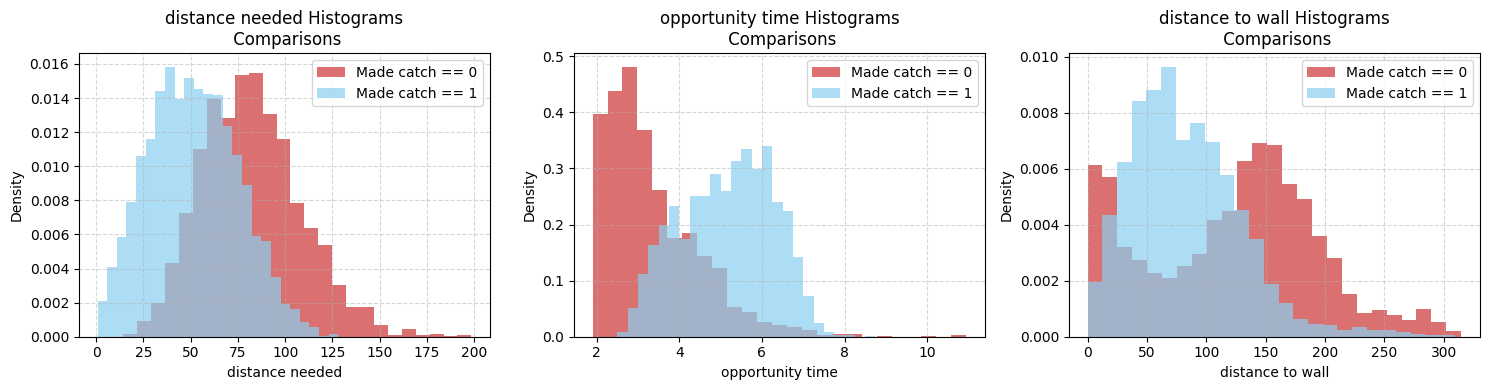

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
catch_made_hist(catch_prob_df, 'distance_needed', ax=ax1)
catch_made_hist(catch_prob_df, 'opportunity_time', ax=ax2)
catch_made_hist(catch_prob_df, 'distance_to_wall', ax=ax3)
plt.tight_layout()
plt.show()

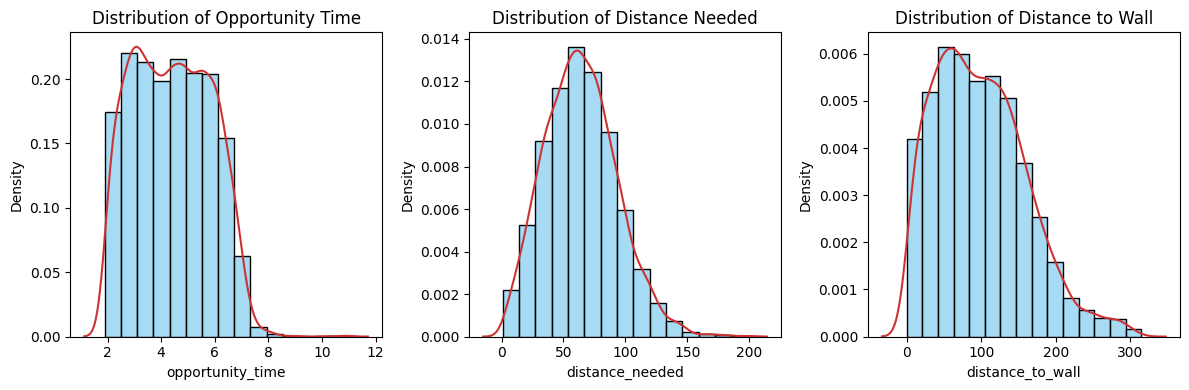

In [20]:
## Plots of our models's features' histograms
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(data=catch_prob_df, x='opportunity_time', stat='density', bins=15, color='#89CFF0', ax=ax1)
sns.kdeplot(data=catch_prob_df, x='opportunity_time', color='#CC3433', ax=ax1)
ax1.set_title('Distribution of Opportunity Time')

sns.histplot(data=catch_prob_df, x='distance_needed', stat='density', bins=15, color='#89CFF0', ax=ax2)
sns.kdeplot(data=catch_prob_df, x='distance_needed', color='#CC3433', ax=ax2)
ax2.set_title('Distribution of Distance Needed')

sns.histplot(data=catch_prob_df, x='distance_to_wall', stat='density', bins=15, color='#89CFF0', ax=ax3)
sns.kdeplot(data=catch_prob_df, x='distance_to_wall', color='#CC3433', ax=ax3)
ax3.set_title('Distribution of Distance to Wall')

plt.tight_layout()
plt.show()

The observed distribution of opportunity time seems roughly Uniform from 2 to around 7 -> use bootstrapping to find the estimated alpha and beta
* Opportunity Time ~ Unif($\alpha \approx$ 2, $\beta\approx$ 7)

The observed distribution of distance needed seems roughly Normal as its shape replicates a bell curve with a heavy-ish right-tail -> use MLE to find $\hat\mu$ and $\hat\sigma^2$
* Distance Needed ~ N($\hat\mu$, $\hat\sigma^2$)

The observed distribution of distance to wall looks roughly like a Gamma distribution, given the skewed right nature -> use MLE to find $\hat\beta$ and trial+error to find $\hat\alpha$
* Distance to Wall ~ Gamma($\hat\alpha, \hat\beta$)

In [21]:
## filters opportunity_time to be within (2.5%, 97.5%) of the data -> im using the central 95% because of the observed outliers in opportunity_time
lower_ot_95, upper_ot_95 = np.percentile(catch_prob_df['opportunity_time'], [2.5, 97.5])
opportunity_time_95 = catch_prob_df['opportunity_time'][(catch_prob_df['opportunity_time'] >= lower_ot_95) & (catch_prob_df['opportunity_time'] <= upper_ot_95)].values
## computes the estimated alpha and beta of opportunity_time ~ Unif(alpha, beta) where alpha and beta are the sample min and max after filtering
unif_distrib = np.random.uniform(low=np.min(opportunity_time_95), high=np.max(opportunity_time_95), size=len(opportunity_time_95))
opportunity_time_alpha, opportunity_time_beta = bootstrap_uniform(unif_distrib)
opportunity_time_alpha, opportunity_time_beta

(2.100572815136692, 6.896664684766612)

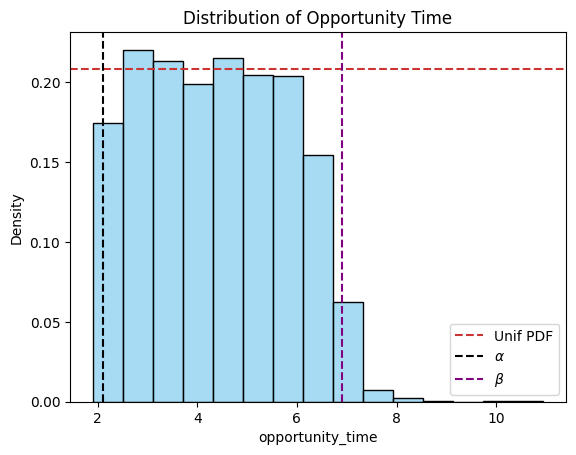

In [22]:
## plotting the unif pdf onto Opportunity Time
plt.figure()
unif_pdf = 1 / (np.max(opportunity_time_95) - np.min(opportunity_time_95))
plt.axhline(y=unif_pdf, color='#CC3433', linestyle='--', label='Unif PDF')
plt.axvline(x=np.min(opportunity_time_95), color='black', linestyle='--', label=r'$\alpha$')
plt.axvline(x=np.max(opportunity_time_95), color='purple', linestyle='--', label=r'$\beta$')
sns.histplot(data=catch_prob_df, x='opportunity_time', stat='density', bins=15, color='#89CFF0')
plt.title('Distribution of Opportunity Time')
plt.legend()
plt.show()

In [24]:
## computes the sample mean, std, and var -> these are the MLE estimates for the Normal distrib
x_bar = np.mean(catch_prob_df['distance_needed'])
s_sq_hat = np.var(catch_prob_df['distance_needed'])
s_hat = s_sq_hat ** (1/2)
x_bar, s_hat, s_sq_hat

(64.21096528927843, 29.000585021472798, 841.0339315876723)

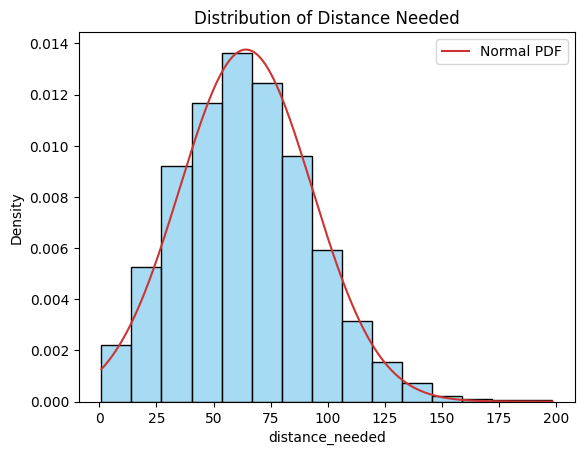

In [25]:
## Plots of our models's features' histograms
plt.figure()
sns.histplot(data=catch_prob_df, x='distance_needed', stat='density', bins=15, color='#89CFF0')
x_values = np.linspace(catch_prob_df['distance_needed'].min(), catch_prob_df['distance_needed'].max(), len(catch_prob_df['distance_needed']))
normal_pdf = (1 / (s_hat * np.sqrt(2*np.pi))) * np.exp((-(x_values-x_bar)**2) / (2 * s_sq_hat))
plt.plot(x_values, normal_pdf, color='#CC3433', label='Normal PDF')
# sns.kdeplot(data=catch_prob_df, x='distance_needed', color='#CC3433', ax=ax2)
plt.title('Distribution of Distance Needed')
plt.legend()
plt.show()

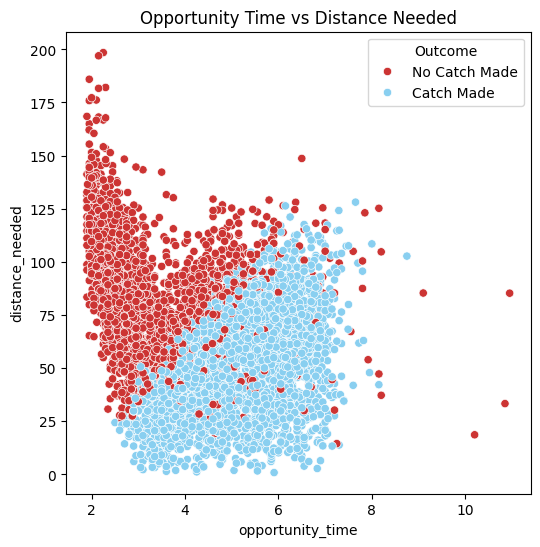

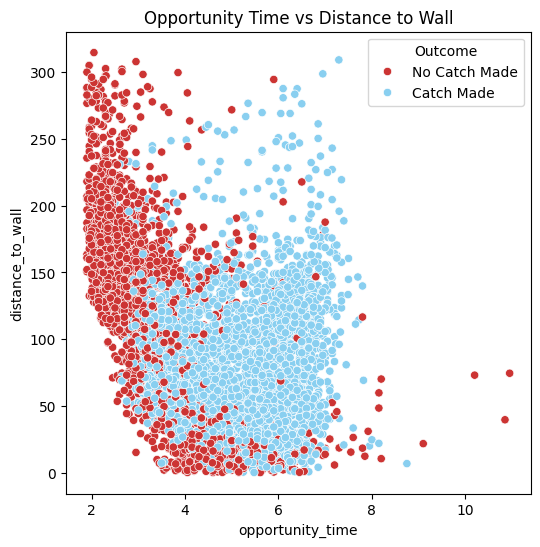

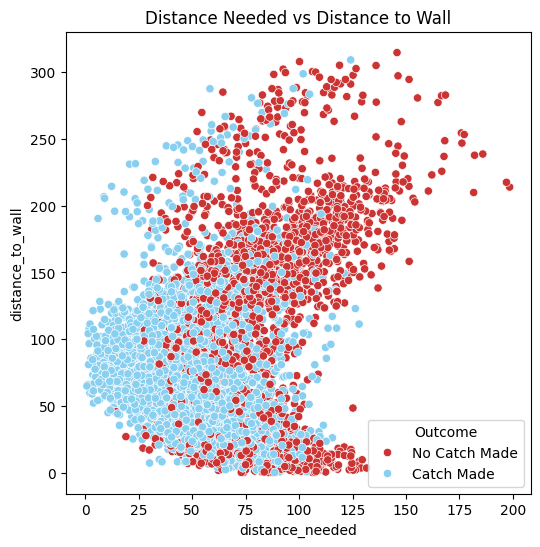

In [26]:
plt.figure(figsize=(6, 6))
scatter_plot = sns.scatterplot(data=catch_prob_df, x='opportunity_time', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
handles, labels = scatter_plot.get_legend_handles_labels()
scatter_plot.legend(handles=handles, labels=['No Catch Made', 'Catch Made'], title='Outcome')
plt.title('Opportunity Time vs Distance Needed')
plt.show()

plt.figure(figsize=(6, 6))
scatter_plot = sns.scatterplot(data=catch_prob_df, x='opportunity_time', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
handles, labels = scatter_plot.get_legend_handles_labels()
scatter_plot.legend(handles=handles, labels=['No Catch Made', 'Catch Made'], title='Outcome')
plt.title('Opportunity Time vs Distance to Wall')
plt.show()

plt.figure(figsize=(6, 6))
scatter_plot = sns.scatterplot(data=catch_prob_df, x='distance_needed', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
handles, labels = scatter_plot.get_legend_handles_labels()
scatter_plot.legend(handles=handles, labels=['No Catch Made', 'Catch Made'], title='Outcome')
plt.title('Distance Needed vs Distance to Wall')
plt.show()

### Catch Probability Baseline GAM

In [27]:
## baseline model with only opportunity time + distance needed
X = catch_prob_df[['opportunity_time', 'distance_needed']].copy()
y = catch_prob_df['is_out_catch'].values

X = scaler.fit_transform(X[['opportunity_time', 'distance_needed']])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

grid_gam = LogisticGAM(s(0, lam=10) + s(1, lam=10)).gridsearch(X_train, y_train, lam=np.logspace(-3, 3, 10))
print(grid_gam.lam)
gam = LogisticGAM(s(0, lam=10) + s(1, lam=10)).fit(X_train, y_train)
y_pred_proba = gam.predict_proba(X_test)
y_pred = gam.predict(X_test)

y_val_pred_proba = gam.predict_proba(X_val)
y_val_pred = gam.predict(X_val)
gam.summary()

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow en

did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
 40% (4 of 10) |##########               | Elapsed Time: 0:00:17 ETA:   0:00:26
 50% (5 of 10) |############             | Elapsed Time: 0:00:17 ETA:   0:00:17
 60% (6 of 10) |###############          | Elapsed Time: 0:00:18 ETA:   0:00:12
 70% (7 of 10) |#################        | Elapsed Time: 0:00:18 ETA:   0:00:07
 80% (8 of 10) |####################     | Elapsed Time: 0:00:18 ETA:   0:00:04
 90% (9 of 10) |######################   | Elapsed Time: 0:00:18 ETA:   0:00:02
100% (10 of 10) |########################| Elapsed Time: 0:00:18 Time:  0:00:18


[[10.0], [10.0]]
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                      8.5026
Link Function:                        LogitLink Log Likelihood:                                  -744.0628
Number of Samples:                         3187 AIC:                                             1505.1308
                                                AICc:                                            1505.1936
                                                UBRE:                                               2.4744
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                    0.655
Feature Function    

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_33250/2177827806.py:18: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


#### Results

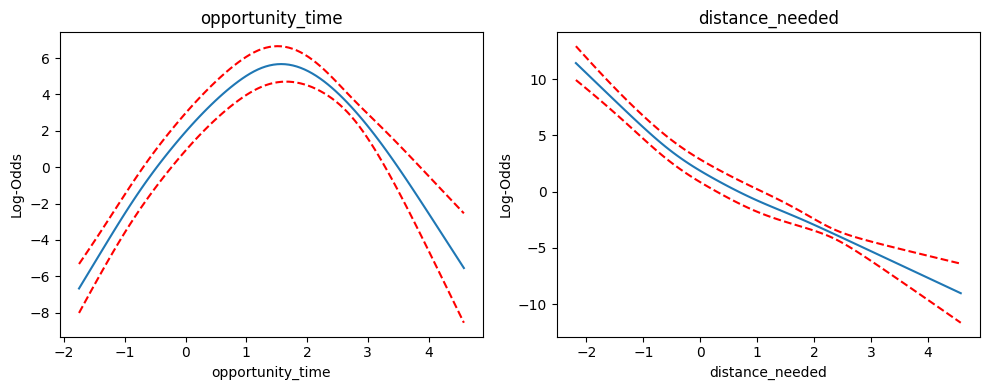

In [28]:
partial_dependence_plots(gam, ['opportunity_time', 'distance_needed'])

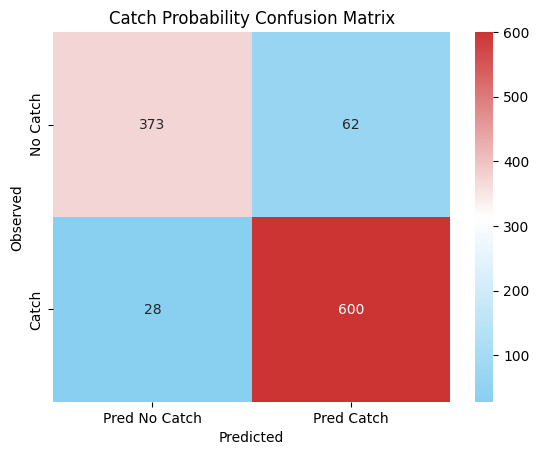

,precision,recall,f1_score,roc_auc,log_loss
test_baseline,0.906344,0.955414,0.930233,0.95604,0.26007


In [29]:
## test set results
catch_prob_cm(y_test, y_pred)
test_baseline_df = accuracy_metric_df(y_test, y_pred, y_pred_proba, 'test_baseline').copy()
test_baseline_df

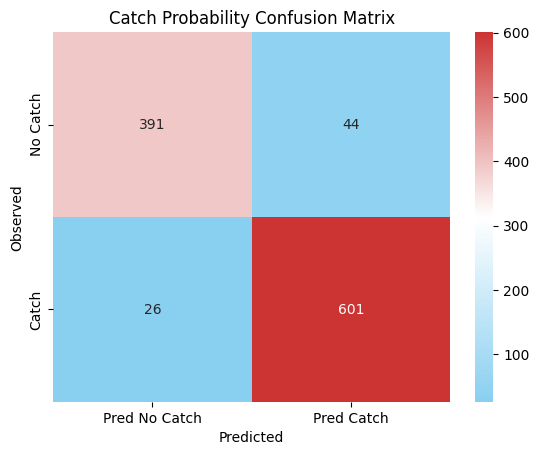

,precision,recall,f1_score,roc_auc,log_loss
val_baseline,0.931783,0.958533,0.944969,0.975409,0.195225


In [30]:
## validation set results
catch_prob_cm(y_val, y_val_pred)
val_baseline_df = accuracy_metric_df(y_val, y_val_pred, y_val_pred_proba, 'val_baseline')
val_baseline_df

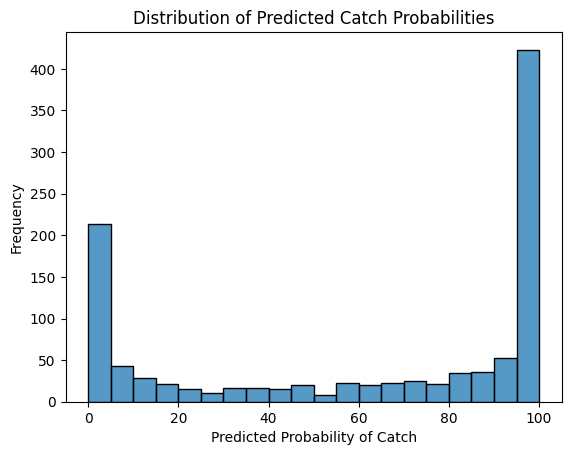

,opportunity_time,distance_needed,predicted,predicted_prob,actual_outcome
0,0.591012,0.978213,True,55,1.0
1,-0.284280,-0.021709,False,40,1.0
2,0.935527,-0.656299,True,100,1.0
3,-1.334631,0.604275,False,0,0.0
4,1.443897,0.476741,True,95,1.0
...,...,...,...,...,...
1058,0.065837,-1.500453,True,100,1.0
1059,-1.019525,0.085723,False,0,0.0
1060,-0.284280,-0.528883,True,80,1.0
1061,1.291246,-1.807721,True,100,1.0


In [31]:
probs_df = pd.DataFrame({'opportunity_time': X_test[:, 0],
                         'distance_needed': X_test[:, 1],
                         'predicted': np.array([i for i in y_pred]),
                         'predicted_prob': np.array([round((i*100)/5)*5 for i in y_pred_proba]),
                         'actual_outcome': y_test}
                         )
sns.histplot(data=probs_df, x='predicted_prob', bins=20, edgecolor='k')
plt.xlabel('Predicted Probability of Catch')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Catch Probabilities')
plt.show()

probs_df

### Catch Probability Improved? GAM

In [32]:
## model with opportunity time + distance needed + now direction angle
## turning direction_angle into a categorical feature
X2 = catch_prob_df[['opportunity_time', 'distance_needed', 'direction_angle']].copy()
X2.loc[:, 'direction_cat_code'] = X2['direction_angle'].astype('category').cat.codes
direction_categories = X2['direction_angle'].astype('category').cat.categories

X2_scaled = scaler.fit_transform(X2[['opportunity_time', 'distance_needed']].values)
X2 = np.hstack([X2_scaled, X2[['direction_cat_code']].values])
y2 = catch_prob_df['is_out_catch'].values

X2_train, X2_temp, y2_train, y2_temp = train_test_split(X2, y2, test_size=0.4, stratify=y2, random_state=42)
X2_val, X2_test, y2_val, y2_test = train_test_split(X2_temp, y2_temp, test_size=0.5, stratify=y2_temp, random_state=42)

grid_gam_w_direction = LogisticGAM(s(0) + s(1) + f(2)).gridsearch(X2_train, y2_train, lam=np.logspace(-3, 3, 10))
print(grid_gam_w_direction.lam)
gam_w_direction = LogisticGAM(s(0, lam=10) + s(1, lam=10) + f(2, lam=10)).fit(X2_train, y2_train)

y2_pred_proba = gam_w_direction.predict_proba(X2_test)
y2_pred = gam_w_direction.predict(X2_test)
y2_val_pred_proba = gam_w_direction.predict_proba(X2_val)
y2_val_pred = gam_w_direction.predict(X2_val)
gam_w_direction.summary()

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow en

did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
 30% (3 of 10) |#######                  | Elapsed Time: 0:00:06 ETA:   0:00:15
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero en

did not converge


 40% (4 of 10) |##########               | Elapsed Time: 0:00:07 ETA:   0:00:10
 50% (5 of 10) |############             | Elapsed Time: 0:00:07 ETA:   0:00:07
 60% (6 of 10) |###############          | Elapsed Time: 0:00:07 ETA:   0:00:04
 70% (7 of 10) |#################        | Elapsed Time: 0:00:07 ETA:   0:00:03
 80% (8 of 10) |####################     | Elapsed Time: 0:00:08 ETA:   0:00:02
 90% (9 of 10) |######################   | Elapsed Time: 0:00:08 ETA:   0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:08 Time:  0:00:08


[[10.0], [10.0], [10.0]]
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     12.4125
Link Function:                        LogitLink Log Likelihood:                                  -716.8825
Number of Samples:                         3187 AIC:                                             1458.5899
                                                AICc:                                            1458.7118
                                                UBRE:                                               2.4608
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6676
Feature Func

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_33250/1190683474.py:22: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_w_direction.summary()


#### Results

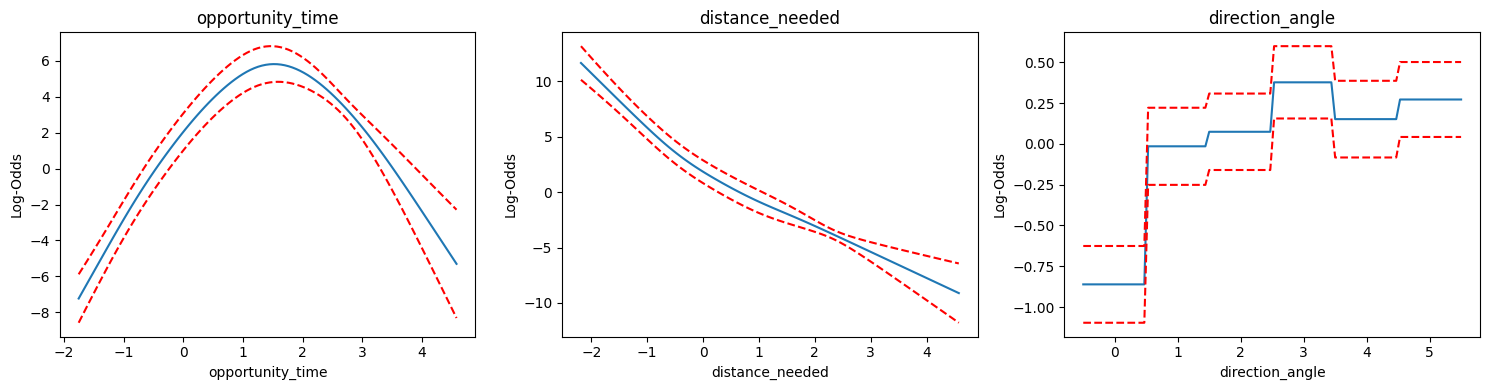

In [33]:
partial_dependence_plots(gam_w_direction, ['opportunity_time', 'distance_needed', 'direction_angle'])

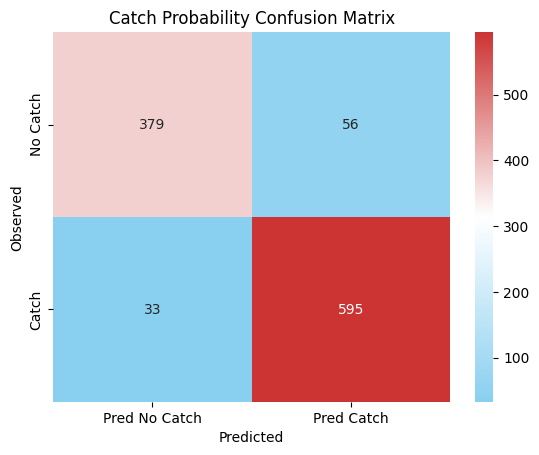

,precision,recall,f1_score,roc_auc,log_loss
test_2nd_model,0.913978,0.947452,0.930414,0.95794,0.253622


In [34]:
## test set results
catch_prob_cm(y2_test, y2_pred)
test_model2_df = accuracy_metric_df(y2_test, y2_pred, y2_pred_proba, 'test_2nd_model')
test_model2_df

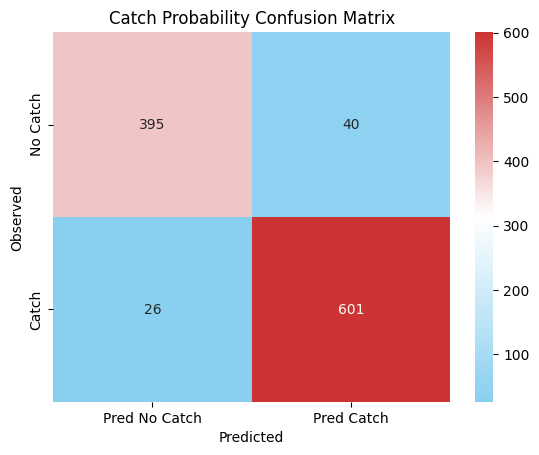

,precision,recall,f1_score,roc_auc,log_loss
val_2nd_model,0.937598,0.958533,0.94795,0.977338,0.1888


In [35]:
## validation set results
catch_prob_cm(y2_val, y2_val_pred)
val_model2_df = accuracy_metric_df(y2_val, y2_val_pred, y2_val_pred_proba, 'val_2nd_model')
val_model2_df

### Catch Probability Improved?? GAM

In [36]:
## model with opportunity time + distance needed + direction angle + now distance to wall
## turning direction_angle into a categorical feature
X3 = catch_prob_df[['opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle']].copy()
X3.loc[:, 'direction_cat_code'] = X3['direction_angle'].astype('category').cat.codes
direction_categories = X3['direction_angle'].astype('category').cat.categories

X3_scaled = scaler.fit_transform(X3[['opportunity_time', 'distance_needed', 'distance_to_wall']].values)
X3 = np.hstack([X3_scaled, X3[['direction_cat_code']].values])
y3 = catch_prob_df['is_out_catch'].values

X3_train, X3_temp, y3_train, y3_temp = train_test_split(X3, y3, test_size=0.4, stratify=y3, random_state=42)
X3_val, X3_test, y3_val, y3_test = train_test_split(X3_temp, y3_temp, test_size=0.5, stratify=y3_temp, random_state=42)

grid_gam_w_wall = LogisticGAM(s(0) + s(1) + s(2) + f(3)).gridsearch(X3_train, y3_train, lam=np.logspace(-3, 3, 10))
print(grid_gam_w_wall.lam)
gam_w_wall = LogisticGAM(s(0, lam=10) + s(1, lam=10) + s(2, lam=10) + f(3, lam=10)).fit(X3_train, y3_train)

y3_pred_proba = gam_w_wall.predict_proba(X3_test)
y3_pred = gam_w_wall.predict(X3_test)
y3_val_pred_proba = gam_w_wall.predict_proba(X3_val)
y3_val_pred = gam_w_wall.predict(X3_val)
gam_w_wall.summary()

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow en

did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
 30% (3 of 10) |#######                  | Elapsed Time: 0:00:05 ETA:   0:00:13
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow en

did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: overflow encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
 40% (4 of 10) |##########               | Elapsed Time: 0:00:09 ETA:   0:00:13
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow e

did not converge


 50% (5 of 10) |############             | Elapsed Time: 0:00:10 ETA:   0:00:10
 60% (6 of 10) |###############          | Elapsed Time: 0:00:10 ETA:   0:00:07
 70% (7 of 10) |#################        | Elapsed Time: 0:00:11 ETA:   0:00:04
 80% (8 of 10) |####################     | Elapsed Time: 0:00:11 ETA:   0:00:02
 90% (9 of 10) |######################   | Elapsed Time: 0:00:12 ETA:   0:00:01
100% (10 of 10) |########################| Elapsed Time: 0:00:12 Time:  0:00:12


[[10.0], [10.0], [10.0], [10.0]]
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     16.9015
Link Function:                        LogitLink Log Likelihood:                                   -655.612
Number of Samples:                         3187 AIC:                                             1345.0271
                                                AICc:                                            1345.2407
                                                UBRE:                                               2.4263
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                    0.696
Feat

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_33250/2183010166.py:22: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_w_wall.summary()


#### Results

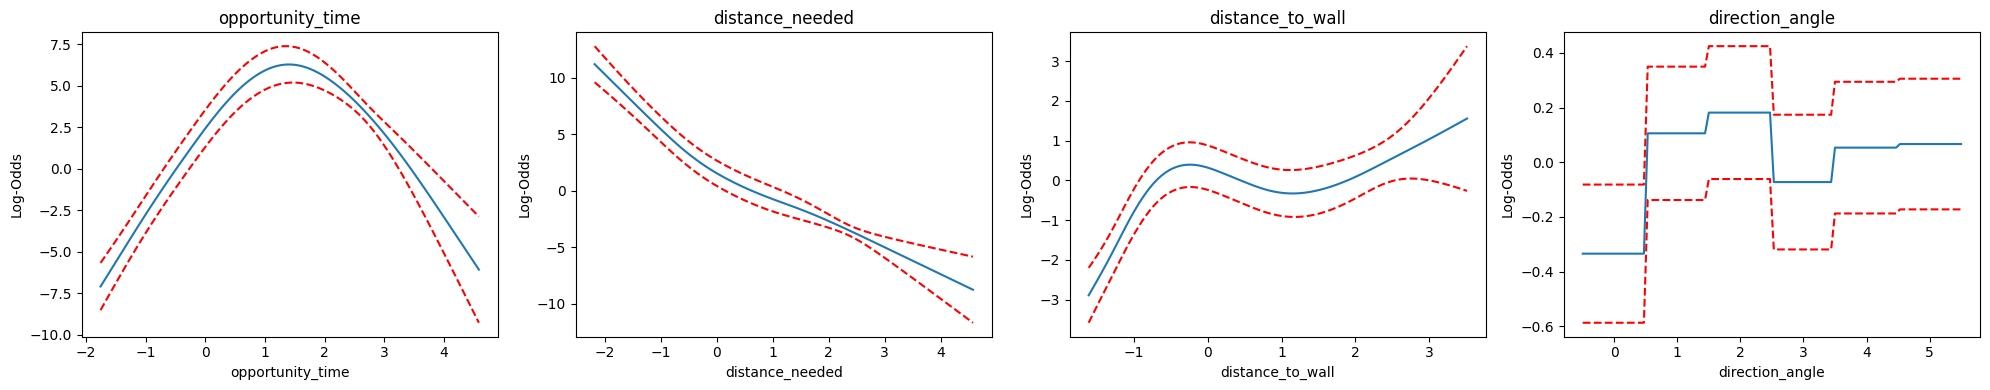

In [37]:
partial_dependence_plots(gam_w_wall, ['opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle'])

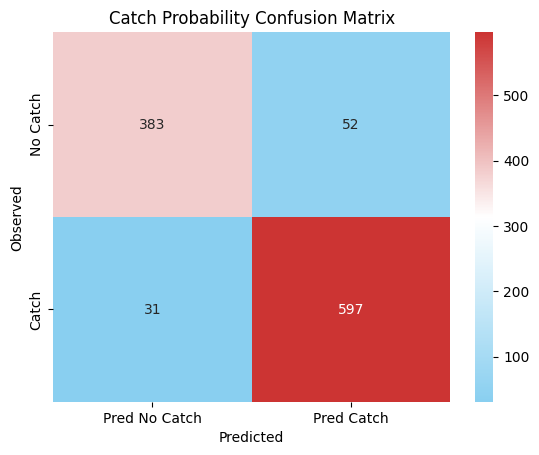

,precision,recall,f1_score,roc_auc,log_loss
test_3rd_model,0.919877,0.950637,0.935004,0.964624,0.231648


In [38]:
## test set results
catch_prob_cm(y3_test, y3_pred)
test_model3_df = accuracy_metric_df(y3_test, y3_pred, y3_pred_proba, 'test_3rd_model')
test_model3_df

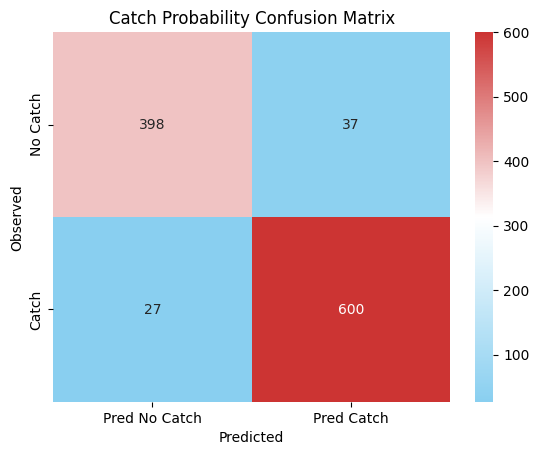

,precision,recall,f1_score,roc_auc,log_loss
val_3rd_model,0.941915,0.956938,0.949367,0.980432,0.173882


In [39]:
## validation set results
catch_prob_cm(y3_val, y3_val_pred)
val_model3_df = accuracy_metric_df(y3_val, y3_val_pred, y3_val_pred_proba, 'val_3rd_model')
val_model3_df

### All 3 GAM Results

In [40]:
gam_results = pd.concat([test_baseline_df, val_baseline_df, test_model2_df, val_model2_df, test_model3_df, val_model3_df]).copy()
gam_results

,precision,recall,f1_score,roc_auc,log_loss
test_baseline,0.906344,0.955414,0.930233,0.956040,0.260070
val_baseline,0.931783,0.958533,0.944969,0.975409,0.195225
test_2nd_model,0.913978,0.947452,0.930414,0.957940,0.253622
val_2nd_model,0.937598,0.958533,0.947950,0.977338,0.188800
test_3rd_model,0.919877,0.950637,0.935004,0.964624,0.231648
val_3rd_model,0.941915,0.956938,0.949367,0.980432,0.173882


The 3rd model fared the best with the test set across all the accuracy metrics. It also was either the second or best model in with respect to the validation set --> safe to say that it's the model we'll use

In [41]:
gam_w_wall

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + s(1) + s(2) + f(3) + intercept, tol=0.0001, 
   verbose=False)

In [42]:
## applies the gam_w_wall model to the catch_prob_df to merge onto catch_prob_df
## prepares the features of catch_prob_df to fit the model
X_catch_prob = catch_prob_df[['game_str_id', 'opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle']].copy()
X_catch_prob.loc[:, 'direction_cat_code'] = X_catch_prob['direction_angle'].astype('category').cat.codes
X_catch_prob_scaled = scaler.transform(X_catch_prob[['opportunity_time', 'distance_needed', 'distance_to_wall']].values)
X_catch_prob_params = np.hstack([X_catch_prob_scaled, X_catch_prob[['direction_cat_code']].values])
## adds the features for catch_prob_df
X_catch_prob.loc[:, 'p_catch'] = gam_w_wall.predict_proba(X_catch_prob_params).astype(float)
X_catch_prob.loc[:, 'p_catch'] = X_catch_prob['p_catch'].apply(lambda x: np.round(x * 20) / 20) ## rounds the prob to be a factor of 5 (like Statcast)
X_catch_prob.loc[:, 'p_catch'] = X_catch_prob['p_catch'].apply(lambda x: 0.95 if x == 1 else x) ## catch probs of 100% become 95% (always some uncertainty)
X_catch_prob.loc[:, 'pred_catch'] = gam_w_wall.predict(X_catch_prob_params).astype(int)
X_catch_prob.loc[:, 'difficulty_level'] = X_catch_prob['p_catch'].apply(assign_difficulty)
X_catch_prob = X_catch_prob[['game_str_id', 'p_catch', 'pred_catch', 'difficulty_level']].copy()

In [43]:
X_catch_prob['difficulty_level'].value_counts(normalize=True).sort_index(ascending=False)

difficulty_level
5 Star    0.331514
4 Star    0.068712
3 Star    0.088667
2 Star    0.104480
1 Star    0.406627
Name: proportion, dtype: float64

In [44]:
catch_prob_df = catch_prob_df.merge(X_catch_prob, on='game_str_id', how='left').copy()

In [45]:
catch_prob_df.to_csv('catch_probabilities.csv')

In [47]:
catch_prob_df[(catch_prob_df['difficulty_level'] == '5 Star') & (catch_prob_df['is_out_catch'] == 1)].sort_values(by='p_catch', ascending=True)

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level
482,y1_d020_JFU_YJD_170,109.978688,66.830220,6.911767,8.750,8.300,In Left,In Left,In Left,102.693719,245.395963,361.870524,22.787296,10.716745,5.470245,6.737287,45.322555,95.001248,1.0,1,-0.698400,7.0,7.0,0.0,9.743935,2.665413,0.965532,29.393208,12.583199,0.120952,38.440248,13.203850,0.706252,170.0,y1_d020_JFU_YJD,1.0,YJD-0193,YJD-0338,YJD-0327,102.693719,109.978688,In Left,22.787296,9.743935,29.393208,38.440248,y1,JFU,YJD,0.00,0,5 Star
5303,y2_d098_YJD_RZQ_146,31.674520,43.096223,17.088897,3.050,2.600,Back Right,In Left,In Left,88.069567,50.588403,168.929430,18.480465,21.880673,10.438544,148.605086,29.680839,96.417483,1.0,0,NaN,8.0,8.0,0.0,4.993828,10.565666,2.709817,25.861166,32.851714,14.231103,31.346052,43.907987,16.284059,146.0,y2_d098_YJD_RZQ,0.0,YJD-0185,YJD-0019,YJD-0397,50.588403,43.096223,In Left,21.880673,10.565666,32.851714,43.907987,y2,YJD,RZQ,0.10,0,5 Star
4835,y2_d075_VZE_YJD_265,43.126469,77.889496,58.186403,4.917,4.488,Back Right,Back,Back Left,185.090908,91.051512,228.965854,12.789485,24.740314,16.196216,6.946850,42.482536,98.940939,1.0,1,4.615620,8.0,8.0,0.0,5.112066,2.851667,4.998708,14.800831,29.535645,21.742491,16.174966,32.443235,25.344821,265.0,y2_d075_VZE_YJD,0.0,VZE-1724,VZE-2346,VZE-1476,91.051512,77.889496,Back,24.740314,2.851667,29.535645,32.443235,y2,VZE,YJD,0.10,0,5 Star
1241,y1_d049_JZK_RZQ_164,28.001224,55.970734,69.406501,4.400,3.950,Back Right,Back Right,Back,267.188456,130.127747,78.799234,12.396078,17.755103,24.005946,19.564526,36.614927,103.794640,1.0,0,NaN,9.0,9.0,0.0,3.618473,7.070598,5.420746,7.972971,24.404565,29.470073,9.793232,28.534147,35.757574,164.0,y1_d049_JZK_RZQ,0.0,JZK-1207,JZK-1781,JZK-1356,78.799234,69.406501,Back,24.005946,5.420746,29.470073,35.757574,y1,JZK,RZQ,0.10,0,5 Star
1591,y1_d057_OXG_QEA_354,80.122507,11.672841,1.434719,4.600,4.200,In Left,In Left,In Left,83.898672,209.629964,355.764744,22.483437,4.003454,0.823619,11.453336,41.866335,87.993939,1.0,0,NaN,7.0,7.0,0.0,12.671551,1.364406,1.236776,31.130547,4.384824,0.441803,42.506219,4.803394,0.563161,354.0,y1_d057_OXG_QEA,0.0,OXG-0018,OXG-0085,OXG-0134,83.898672,80.122507,In Left,22.483437,12.671551,31.130547,42.506219,y1,OXG,QEA,0.10,0,5 Star
2606,y1_d089_CRQ_QEA_113,11.771874,17.511325,69.603965,4.300,3.900,Back Right,In Right,Back Right,327.469368,202.388170,70.844799,4.178725,5.112800,25.760865,9.223663,56.954893,94.169678,1.0,0,NaN,9.0,9.0,0.0,1.204222,4.439600,7.677780,4.975350,7.239809,28.777871,6.149651,10.995894,30.538255,113.0,y1_d089_CRQ_QEA,1.0,QEA-0421,QEA-0182,QEA-0249,70.844799,69.603965,Back Right,25.760865,7.677780,28.777871,30.538255,y1,CRQ,QEA,0.10,0,5 Star
4636,y2_d067_HKR_RZQ_111,47.010263,73.284892,45.420722,4.950,4.500,Back Right,Back,Back Left,184.103973,82.492493,199.086874,13.044698,28.222682,12.962992,2.318308,36.462974,103.500961,1.0,1,-0.517491,8.0,8.0,0.0,5.714704,6.542035,12.716828,16.255547,15.995787,16.532274,21.261924,23.457076,16.113305,111.0,y2_d067_HKR_RZQ,1.0,RZQ-0143,RZQ-0274,RZQ-0346,82.492493,73.284892,Back,28.222682,6.542035,15.995787,23.457076,y2,HKR,RZQ,0.15,0,5 Star
4201,y2_d050_DYE_RZQ_17,8.344355,15.333405,28.755257,2.700,2.300,In Right,In Right,In,242.825325,140.975901,39.094352,6.413033,8.304545,17.376932,111.646381,98.093408,99.212868,1.0,0,NaN,9.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,